# Notebook 10 — KEMs are half the story: signatures and friends

Up to now we've implemented **one** of the three FIPS 2024 standards: ML-KEM (a KEM). This notebook sketches the other two — **ML-DSA** and **SLH-DSA** — and shows where each fits in the broader post-quantum landscape.

The goal is orientation, not implementation: once you've built a lattice KEM from the inside, most of the ideas generalize.

## Why two things? KEM vs signature

| Capability | KEM (ML-KEM) | Signature (ML-DSA / SLH-DSA) |
|------------|--------------|-------------------------------|
| Goal | Agree on a shared secret between two parties | Prove this message came from a specific signer, unmodified |
| Key pair | `(ek, dk)` — encapsulation / decapsulation | `(vk, sk)` — verification / signing |
| Core operation | `Decaps(dk, ct) -> K` | `Verify(vk, msg, sig) -> ok?` |
| Used in TLS | Key exchange (replacing X25519) | Certificate signing (replacing RSA/ECDSA) |

A real TLS 1.3 handshake uses **both**: a KEM to agree on a key, and a signature over the handshake transcript to authenticate the server's certificate. After Q-Day, both must be quantum-safe — hence both FIPS 203 (KEM) and FIPS 204/205 (signatures).

## The three FIPS 2024 standards at a glance

| Standard | Name | Family | Role | Security rests on |
|----------|------|--------|------|-------------------|
| **FIPS 203** | ML-KEM (Kyber) | Module-LWE (lattice) | Key encapsulation | MLWE hardness |
| **FIPS 204** | ML-DSA (Dilithium) | Module-LWE + Module-SIS (lattice) | Signatures | MLWE + MSIS |
| **FIPS 205** | SLH-DSA (SPHINCS+) | Hash-based | Signatures | Hash collision-resistance only |

## ML-DSA (Dilithium) — same math, different shape

ML-DSA and ML-KEM share the same arithmetic: `R_q = Z_q[x]/(x^n+1)` with `n=256, q=8380417` (different q from ML-KEM's 3329), Module-LWE + Module-SIS, NTT-friendly.

**Signing uses Fiat-Shamir with aborts**:

1. Generate a random nonce y; compute w = A·y.
2. Challenge c = H(message || w) — a hash-derived small polynomial.
3. Response z = y + c·s where s is the secret.
4. If z reveals too much about s, abort and retry. Otherwise output (z, c).

Verification checks the `A·z - c·t = A·y` relation without seeing s. The "aborts" are why Dilithium's signing is non-constant-time — but the output is safe.

**Size comparison** (Level 3 / 128-bit PQ security):

- ML-DSA: vk ≈ 2 KB, sig ≈ 3.3 KB
- ECDSA P-256 (for reference): vk 32 B, sig 64 B — ~50× larger for ML-DSA.

## SLH-DSA (SPHINCS+) — the "boring" backup plan

Hash-based signatures rest only on hash-function security (no number theory, no lattice assumptions). If every other PQC scheme breaks — lattices, codes, multivariate, isogeny — **SPHINCS+ still stands**, as long as SHA-2/SHA-3 remain collision-resistant.

**How it works, intuitively**:

- A **Merkle tree** of many one-time signatures (OTS).
- Each message is signed with a fresh OTS leaf; the path up the Merkle tree proves the leaf belongs to the public root.
- Stateless version (SPHINCS+, what NIST standardized): uses a **hyper-tree** (trees of trees) to avoid needing to track which leaves have been used.

**Trade-offs**:

- Signature size: **~8–50 KB** (ugly).
- Verification is fast (hundreds of hash evaluations).
- Signing is slower than ML-DSA.
- But the **security argument is the strongest** of any signature scheme ever standardized.

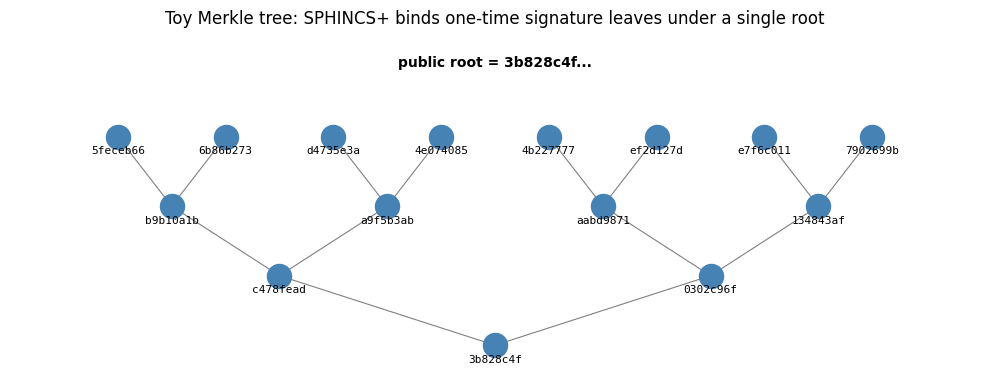

In [1]:
import hashlib
import matplotlib.pyplot as plt

def H(a, b=b""):
    return hashlib.sha256(a + b).digest()

# 8 leaves, each a "one-time signature public key"
leaves = [H(str(i).encode()) for i in range(8)]

# Build the Merkle tree bottom-up
level = leaves
tree = [level]
while len(level) > 1:
    level = [H(level[i], level[i+1]) for i in range(0, len(level), 2)]
    tree.append(level)
root = tree[-1][0]

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
n_levels = len(tree)
for lvl, nodes in enumerate(tree):
    y = n_levels - 1 - lvl
    for i, node in enumerate(nodes):
        x = (i + 0.5) * (8 / len(nodes))
        ax.scatter(x, y, s=300, c="steelblue", zorder=3)
        ax.text(x, y - 0.25, node[:4].hex(), ha="center", fontsize=8, family="monospace")
        if lvl > 0:
            for child in (2*i, 2*i+1):
                cx = (child + 0.5) * (8 / (2 * len(nodes)))
                cy = n_levels - lvl
                ax.plot([x, cx], [y, cy], "gray", lw=0.8, zorder=1)
ax.text(4, n_levels, "public root = " + root[:4].hex() + "...", ha="center", fontsize=10, weight="bold")
ax.set_xlim(-0.5, 8.5)
ax.set_ylim(-0.5, n_levels + 0.5)
ax.axis("off")
plt.title("Toy Merkle tree: SPHINCS+ binds one-time signature leaves under a single root")
plt.tight_layout()
plt.show()


## Trade-off cheatsheet

Choosing between lattice (ML-DSA) and hash-based (SLH-DSA) signatures:

- **Default for new designs**: ML-DSA. Smaller, faster, well-understood.
- **When paranoid about lattice cryptanalysis**: SLH-DSA. Accept the size.
- **When signatures are rare but long-lived** (e.g., code signing a root CA): SLH-DSA's strong security argument is worth the bytes.
- **Hybrid signatures** (ECDSA + ML-DSA, or ECDSA + SLH-DSA) provide defense in depth — same pattern as hybrid KEMs (notebook 08).

## Families not in FIPS 2024, but worth knowing

- **Code-based KEMs** (Classic McEliece, BIKE, HQC): from coding theory. McEliece is from 1978 and has never been broken — but its public keys are ~1 MB. NIST's "alternate track" winners are HQC and a variant of BIKE (expected to standardize around 2026–2027).
- **Isogeny-based** (SIKE): completely broken in 2022 by a classical attack — a cautionary tale about how recent some of this math is.
- **Multivariate** (Rainbow): also broken in 2022.
- **FN-DSA (Falcon)**: a faster lattice signature with smaller signatures than Dilithium, but harder to implement in constant time. NIST plans to standardize as FIPS 206 (late 2025 / 2026).

## Try it: ML-DSA in one line (optional)

If you want to see Dilithium working end-to-end — not from scratch, just the API — install an implementation:

```
pip install pyspx-plus liboqs-python   # requires liboqs shared library
```

This book deliberately does **not** build ML-DSA from scratch; that would roughly double its length. The goal here was to make you comfortable with one lattice-based PQC scheme (ML-KEM) from the inside — the same math applies to ML-DSA.

→ Next: `11_deployment_and_faq_glossary` for real-world status and quick-reference.